<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# Introduction to Machine Learning with SkLearn
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

# ACTIVITY 1


---
## 🟡 Data Interpretation Questions

---

before attempting do make sure to look at scales of the training and test RMSE values, as well as the context of the problem (e.g., the range of claim amounts) to better understand the implications of these results.

1. A claimant support cost model shows:

* Training RMSE: **£45**
* Test RMSE: **£47**

👉 Is this more consistent with overfitting, underfitting, or a good fit? Why?

2. Another model shows:

* Training RMSE: **£40**
* Test RMSE: **£120**

👉 What does this gap suggest about the model behaviour?

3. A third model shows:

* Training RMSE: **£150**
* Test RMSE: **£155**

👉 What does this indicate, and what modelling changes might help?






---
# Code - Fitting A Random Forest Regressor
---



ensemble methods are a powerful class of machine learning algorithms that combine the predictions of multiple base models to improve performance. In this exercise, we will use a Random Forest Regressor, which is an ensemble of decision trees.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # new part!!!
from sklearn.metrics import mean_squared_error

# 1. GENERATE DATA
X, y = make_regression(n_samples=150, n_features=10, noise=15, random_state=42)

# 2. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INSTANTIATE AND FIT THE MODEL
# We use RandomForestRegressor here
rf_model = RandomForestRegressor(random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# 4. EVALUATE
y_train_pred = rf_model.predict(X_train)

# 5. CALCULATE RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_pred, y_train))

# 6. RESULTS
print(f"Random Forrest Train RMSE: {train_rmse:.2f}")


Random Forrest Train RMSE: 40.31


In [2]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=10
)
cv_rsme_scores = -cv_scores
pd.Series(cv_rsme_scores).describe()

count     10.000000
mean     106.078395
std       15.894518
min       81.197788
25%       92.802919
50%      110.676859
75%      115.732506
max      129.551896
dtype: float64

<Axes: ylabel='Count'>

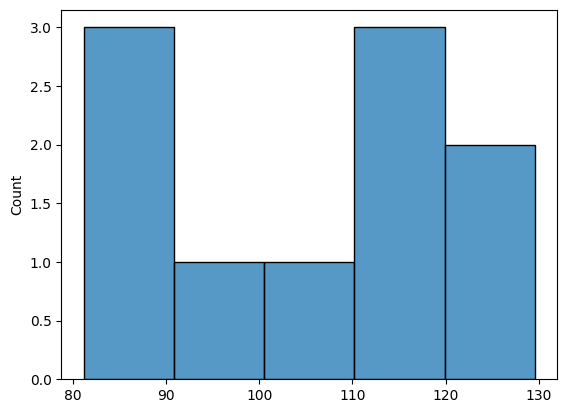

In [3]:
import seaborn as sns
sns.histplot(cv_rsme_scores)

### What did you notice about the training score, compared to the Single Decision Tree? Can you find a simple explaination for this? (use google + gpt to help you if you need to!)

---
# Activity 2 - Cross Validation
---

folowing the same steps as before, we will fit a Decision Tree Regressor and evaluate it using Cross-Validation. This will give us a more reliable estimate of how the model will perform on unseen data using cross-validation with 10 folds.

In [4]:
import numpy as np
import pandas as pd
# from sklearn.____ import RandomForestRegressor # Hint: Random Forest is an ensemble method
# from sklearn.model_selection import ____         # Hint: The function for auditing stability

# # 1. INSTANTIATE
# # We use 100 trees (default) and a random seed for reproducibility
# rf_reg = ____(random_state=42)

# # 2. RUN CROSS-VALIDATION
# cv_scores = ____(
#     rf_reg,
#     X_train,
#     y_train,
#     scoring="____", # Hint: Scikit-learn uses negative utility functions
#     cv=____         # Hint: The number of folds we discussed
# )

# # 3. CONVERT AND SUMMARIZE
# # Flip the sign to get positive RMSE
# rf_rmse_scores = -cv_scores

# # Generate the statistical distribution (mean, std, min, max)
# rf_summary = pd.____(rf_rmse_scores).____()

# print(rf_summary)

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=10
)
cv_rsme_scores = -cv_scores
pd.Series(cv_rsme_scores).describe()

count     10.000000
mean     106.078395
std       15.894518
min       81.197788
25%       92.802919
50%      110.676859
75%      115.732506
max      129.551896
dtype: float64

### Compare the average cross-validation RMSE to the training RMSE of the Random Forest Regressor To the Decision Tree Regressor. What might suggest about the generalization performance of Random Forest compared to the Decision Tree?

---
# Activity 3 - Hyperparameter Tuning
---

Fill in the blanks to complete the code for fitting a Random Forest Regressor and evaluating it using cross-validatio and return the best model

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Setup the "Menu" of options
# We keep this filled: Tuning the number of trees and feature diversity
param_grid = {
    'n_estimators': [30, 100],
    'max_features': [2, 4, 6],
    'max_depth': [2,4,6,8,],
    'bootstrap': [True, False]
}

# 2. Setup the Search
# Hint: Pass the model, the grid, and the number of folds
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    #verbose=3
)

# 3. Run the search
# Hint: Use the training data to find the best combination
grid_search.fit(X_train, y_train)

# 4. Show the winners
# Hint: Access the attributes for the best settings and the best score
# The best combination of parameters found
print(f"Best Parameters: {grid_search.best_params_}")

# The best score (Note: we multiply by -1 to get positive RMSE)
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

Best Parameters: {'bootstrap': False, 'max_depth': 8, 'max_features': 4, 'n_estimators': 100}
Best CV RMSE: 106.2838


Try increasing the number of trees in the forest (n_estimators) or using different ranges see if it improves the performance. so like e.g.  n_estimators = [30, 40, 50, 100] and write down your new best score and the parameters that achieved it.

•••extension - try to find another hyperparameter to tune and see if it improves the performance even more! (e.g. max_depth, min_samples_split, etc.)

---
# Activity 4 - Final Evaluation
---

Label your best model below and then use it to make predictions on the test set and evaluate the RMSE.

In [6]:
 ____________=grid_search.best_estimator_

In [7]:
final_predictions = _______.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

NameError: name '_______' is not defined

### How does the initial RMSE Compare against the Decision Tree?

now take the interval of the RMSE values (just run the cells below)

In [ ]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2


boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [ ]:
print(f"95% Confidence Interval (RMSE): [{rmse_lower:.4f}, {rmse_upper:.4f}]")

How does the interval of the test RMSE values compare to the training RMSE of the Decision Tree? Which model would you choose to deploy and why?